In [2]:
import tensorflow as tf

print(tf.__version__)

2.20.0


Training images: 60000
Test images: 10000
Image shape: (32, 32, 1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8763 - loss: 0.3956Epoch 1 time: 43.02s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.9426 - loss: 0.1876 - val_accuracy: 0.9784 - val_loss: 0.0718
Epoch 2/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9798 - loss: 0.0647Epoch 2 time: 40.93s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9802 - loss: 0.0630 - val_accuracy: 0.9831 - val_loss: 0.0516
Epoch 3/5
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9864 - loss: 0.0439Epoch 3 time: 41.22s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9860 - val_loss: 0.0416
Epoch 4/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9892 - loss: 0.0343Epoch 4 time: 40.81s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9892 - loss: 0.0356 - val_accuracy: 0.9893 - val_loss: 0.0369
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9919 - loss: 0.0

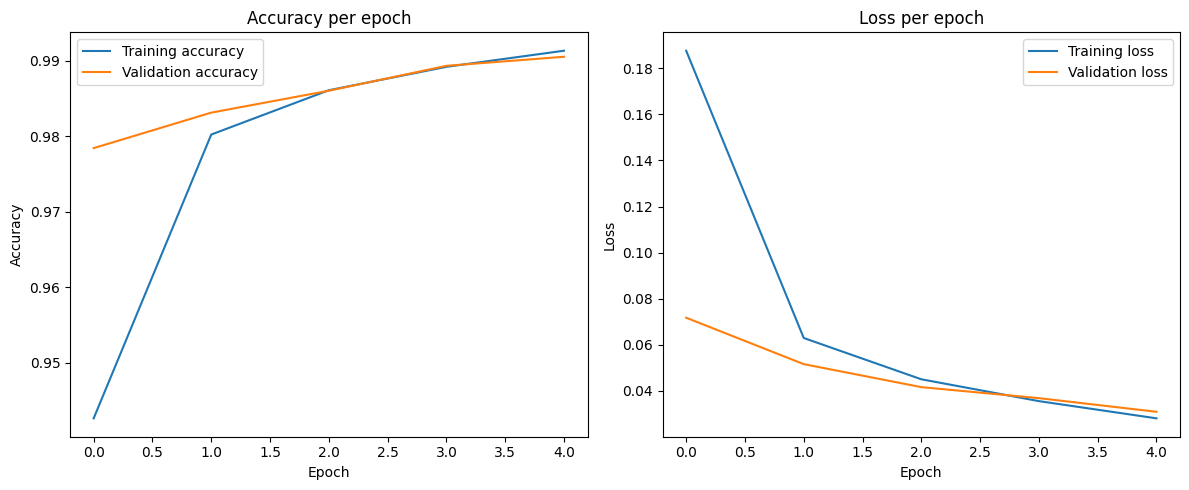

In [ ]:
##
#LeNet-5 implementation for MNIST

import tensorflow as tf
import matplotlib.pyplot as plt
import time

#fixed seed, required for reproducibility
#every time i run the notebook from scratch, i'll get the same initial weights and the same batch shuffle order
#model.fit() shuffles the training data before splitting it into batches each epoch by default. The order examples arrive in affects the gradient updates.
tf.random.set_seed(23)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#MNIST comes as (N, 28, 28) with no channel axis coming from mnist.load_data()
#but LeNet-5 needs (N, H, W, C)
x_train = x_train[..., tf.newaxis] #inserts a new axis of size 1 at the end, turning (N, 28, 28) into (N, 28, 28, 1)
x_test = x_test[..., tf.newaxis]

#zero-pad 28x28 to 32x32
x_train = tf.pad(x_train, [[0,0],[2,2],[2,2],[0,0]])
x_test = tf.pad(x_test, [[0,0],[2,2],[2,2],[0,0]])
#[[0,0],   # batch dimension   - don't add any images, just pad existing ones
#[2,2],   # height (28 -> 32) - add 2 rows of zeros(default) on top, 2 on bottom
#[2,2],   # width  (28 -> 32) - add 2 columns of zeros on left, 2 on right
#[0,0]]   # channel dimension - don't add any channels, still grayscale (1)

#standardize AFTER padding, so the padded border becomes the same constant background value

MNIST_MEAN = 0.1307
MNIST_STD = 0.3081
x_train = (x_train - MNIST_MEAN) / MNIST_STD
x_test = (x_test - MNIST_MEAN) / MNIST_STD

print(f"Training images: {x_train.shape[0]}")
print(f"Test images: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

model = tf.keras.Sequential([
    ##first block contains 1 conv with 6 filters
    tf.keras.layers.Conv2D(6, (5,5),
        activation='relu', #it should be tanh as the paper
       # padding='same' ,## Keras automatically calculates and applies however much padding is needed so the output spatial size exactly matches the input spatial size (for stride 1)
        input_shape=(32,32,1)),
    ##28*28*6

    tf.keras.layers.AveragePooling2D((2,2)), #reducing feature map to quarter it's value
    ## 14*14*6


    ##second block contains 1 conv with 16 filters
    tf.keras.layers.Conv2D(16, (5,5),
        activation='relu',
    ##    padding='same') ,
    ),
    ##10*10*16

    tf.keras.layers.AveragePooling2D((2,2)),
    ##5*5*16

    ##third block contains 1 convs with 120 filters
    tf.keras.layers.Conv2D(120, (5,5),
        activation='relu') ,
    ##1*1*120


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(84, activation='relu'),##this layer is after flatten
                                                  ##so it's input is 1*1*120 = 120


    tf.keras.layers.Dense(10, activation='softmax') ##replacement to the RBF (Euclidean Radial Basis Function)
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

#
#getting training time per epoch
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._start
        self.epoch_times.append(elapsed)
        print(f"Epoch {epoch+1} time: {elapsed:.2f}s")

epoch_timer = EpochTimer()

# added: validation_data so Keras evaluates on the test set at the end of every epoch,
# and capturing the return value of fit() into `history` so we have per-epoch numbers to plot
history = model.fit(x_train, y_train,
          epochs=5, batch_size=32,
          validation_data=(x_test, y_test),
          callbacks=[epoch_timer])

model.evaluate(x_test, y_test)

avg_epoch_time = sum(epoch_timer.epoch_times) / len(epoch_timer.epoch_times)
print(f"Average training time per epoch: {avg_epoch_time:.2f}s")

# added: plot training vs validation accuracy and loss curves across epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()
model.save('lenet5_mnist.keras')

Original shape: (60000, 28, 28)
Prepared shape: (60000, 32, 32, 1) | min: -0.4242 | max: 2.8215
Training images: 60000 | Test images: 10000


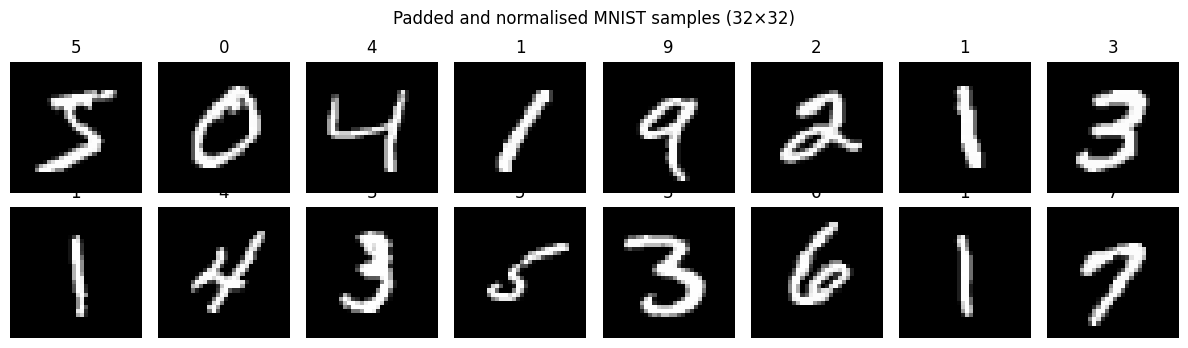

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_16            │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_17            │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9051 - loss: 0.3195Epoch 1 time: 44.91s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9492 - loss: 0.1695 - val_accuracy: 0.9777 - val_loss: 0.0723
Epoch 2/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9801 - loss: 0.0645Epoch 2 time: 43.23s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9813 - loss: 0.0621 - val_accuracy: 0.9849 - val_loss: 0.0469
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9864 - loss: 0.0441Epoch 3 time: 43.32s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9869 - loss: 0.0443 - val_accuracy: 0.9883 - val_loss: 0.0371
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9896 - loss: 0.0334Epoch 4 time: 45.04s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9898 - loss: 0.0338 - val_accuracy: 0.9878 - val_loss: 0.0382
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9914 - loss: 0.0

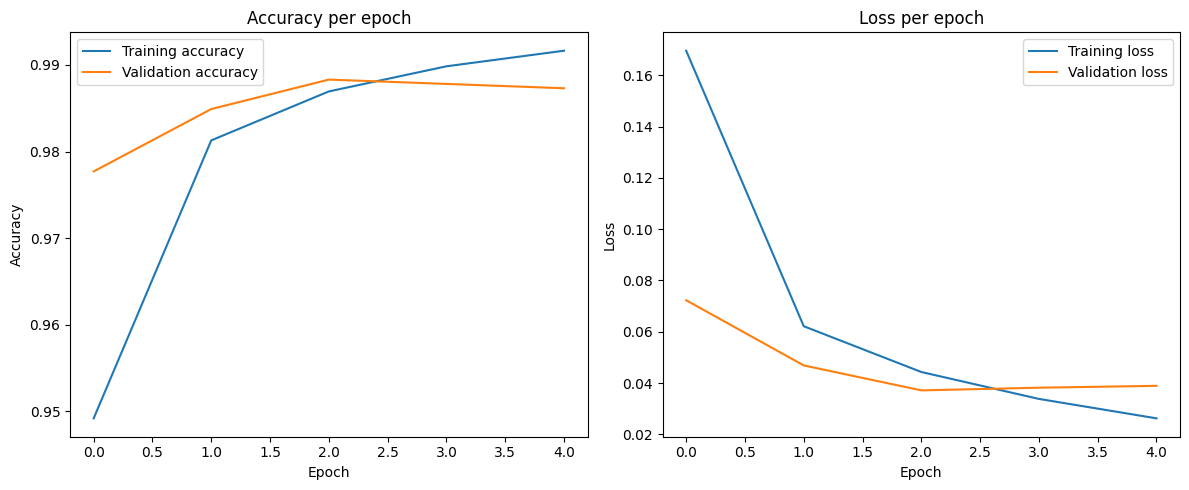

In [15]:
# LeNet-5 training (tanh instead of ReLu)
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


#fixed seed, required for reproducibility
#every time i run the notebook from scratch, i'll get the same initial weights and the same batch shuffle order
#model.fit() shuffles the training data before splitting it into batches each epoch by default. The order examples arrive in affects the gradient updates.
tf.random.set_seed(23)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Original shape:", x_train.shape)

MNIST_mean = 0.1307
MNIST_std = 0.3081
def prepare(images):
  images = np.pad(images, ((0, 0), (2, 2), (2, 2)), mode="constant", constant_values=0) #28x28 to 32x32
  # Using Numpy instead tf in the upper cell
  #[[0,0],   # batch dimension   - don't add any images, just pad existing ones
  #[2,2],   # height (28 -> 32) - add 2 rows of zeros(default) on top, 2 on bottom
  #[2,2],   # width  (28 -> 32) - add 2 columns of zeros on left, 2 on right
  #[0,0]]   # channel dimension - don't add any channels, still grayscale (1) !!!(We didn't add the channel dimension yet as LeNet need the channel dimension and it's)
  images = images.astype('float32') / 255.0
  images = (images - MNIST_mean) / MNIST_std
  images = images[..., tf.newaxis]
  return images

x_train = prepare(x_train)
x_test = prepare(x_test)
print("Prepared shape:", x_train.shape, "| min:", x_train.min().round(4), "| max:", x_train.max().round(4))
print(f"Training images: {len(x_train)} | Test images: {len(x_test)}")

#dah 3shan ashof b3d el padding eh el hasal w keda keda hases el alwan heya heya mt8yrtsh
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, img, label in zip(axes.flat, x_train[:16], y_train[:16]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.suptitle("Padded and normalised MNIST samples (32×32)")
plt.tight_layout()
plt.show()

model = tf.keras.Sequential([
    ##first block contains 1 conv with 6 filters
    tf.keras.layers.Conv2D(6, (5,5),
        activation='tanh', #it should be tanh as the paper
       # padding='same' ,## Keras automatically calculates and applies however much padding is needed so the output spatial size exactly matches the input spatial size (for stride 1)
        input_shape=(32,32,1)),
    ##28*28*6
    tf.keras.layers.AveragePooling2D((2,2)), #reducing feature map to quarter it's value
    ## 14*14*6
    ##second block contains 1 conv with 16 filters
    tf.keras.layers.Conv2D(16, (5,5),
        activation='tanh',
    ##    padding='same') ,
    ),
    ##10*10*16
    tf.keras.layers.AveragePooling2D((2,2)),
    ##5*5*16
    ##third block contains 1 convs with 120 filters
    tf.keras.layers.Conv2D(120, (5,5),
        activation='tanh') ,
    ##1*1*120
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(84, activation='tanh'),##this layer is after flatten
                                                  ##so it's input is 1*1*120 = 120
    tf.keras.layers.Dense(10, activation='softmax') ##replacement to the RBF (Euclidean Radial Basis Function)
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

#getting training time per epoch
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._start
        self.epoch_times.append(elapsed)
        print(f"Epoch {epoch+1} time: {elapsed:.2f}s")

timer = EpochTimer()
# added: validation_data so Keras evaluates on the test set at the end of every epoch,
# and capturing the return value of fit() into `history` so we have per-epoch numbers to plot
history = model.fit(x_train, y_train,
          epochs=5, batch_size=32,
          validation_data=(x_test, y_test),
          callbacks=[epoch_timer])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

avg_epoch_time = sum(epoch_timer.epoch_times) / len(epoch_timer.epoch_times)


print("=" * 45)
print(f"Test accuracy          : {test_acc * 100:.2f}%")
print(f"Test loss              : {test_loss:.4f}")
print(f"Trainable parameters   : {model.count_params():,}")
print(f"Time per epoch (avg)   : {avg_epoch_time:.2f} s  (epochs 2)")
print("=" * 45)
#for i, t in enumerate(timer.epoch_times, 1):
#    print(f"  Epoch {i:2d}: {t:.2f} s")

# added: plot training vs validation accuracy and loss curves across epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

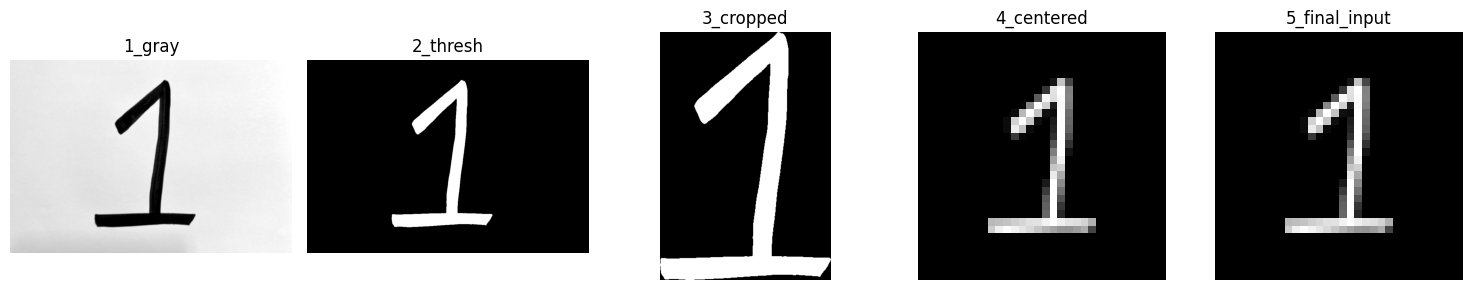

Saved pipeline figure to task2_pipeline_figure6.png
Predicted digit: 1  (confidence: 75.64%)


In [ ]:
"""
preprocess.py - ELCT918 Lab 3, Task 2
Preprocessing pipeline: turns a photo/crop of a handwritten digit into a
32x32 tensor matching the exact distribution LeNet-5 was trained on in Task 1.
wanna run it on my local machine
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# must match EXACTLY what was used to train lenet5_mnist.keras in Task 1
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081


def preprocess(roi):
    """
    roi: a BGR color image (as OpenCV reads it) containing a handwritten
         digit on paper - either a full photo or a cropped camera region.

    Returns:
        tensor: (1, 32, 32, 1) float32 array ready for model.predict(), or
                None if no digit was found in the image.
        steps:  dict of intermediate images, for the Task 2 deliverable figure.
    """
    steps = {}

    # 1. Grayscale + blur (reduce camera sensor noise)
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    steps['1_gray'] = gray

    # 2. Threshold + invert -> white digit on black background, like MNIST
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # if pen strokes are thin and get lost, thicken them:
    # thresh = cv2.dilate(thresh, np.ones((3, 3), np.uint8), iterations=1)
    steps['2_thresh'] = thresh

    # 3. Crop to the digit's bounding box
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        steps['3_cropped'] = thresh  # nothing found, show the blank threshold
        return None, steps
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    digit = thresh[y:y + h, x:x + w]
    steps['3_cropped'] = digit

    # 4. Resize (preserve aspect ratio, larger side -> 20px),
    #    center in 28x28, then pad to 32x32 (matches Task 1's padding)
    h, w = digit.shape
    if h >= w:
        new_h = 20
        new_w = max(1, round(w * 20 / h))
    else:
        new_w = 20
        new_h = max(1, round(h * 20 / w))
    resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas28 = np.zeros((28, 28), dtype=np.uint8)
    y_off = (28 - new_h) // 2
    x_off = (28 - new_w) // 2
    canvas28[y_off:y_off + new_h, x_off:x_off + new_w] = resized

    canvas32 = cv2.copyMakeBorder(canvas28, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=0)
    steps['4_centered'] = canvas32

    # 5. Convert to tensor: scale to [0,1], standardize with the SAME mean/std as training
    tensor = canvas32.astype('float32') / 255.0
    tensor = (tensor - MNIST_MEAN) / MNIST_STD
    tensor = tensor.reshape(1, 32, 32, 1)
    steps['5_final_input'] = canvas32  # keep uint8 version just for display

    return tensor, steps


def show_pipeline_figure(steps, save_path='task2_pipeline_figure6.png'):
    """Deliverable: a figure showing the output of each step for one digit."""
    fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
    if len(steps) == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, steps.items()):
        ax.imshow(img, cmap='gray')
        ax.set_title(name)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved pipeline figure to {save_path}")


if __name__ == "__main__":
    # ---- quick standalone test / Task 2 deliverable generation ----
    # replace with a photo of a handwritten digit on paper (phone photo or
    # a single webcam frame saved to disk)
    IMAGE_PATH = "my_digit_photo6.jpg"

    roi = cv2.imread(IMAGE_PATH)
    if roi is None:
        raise FileNotFoundError(f"Could not read {IMAGE_PATH} - check the path.")

    tensor, steps = preprocess(roi)
    show_pipeline_figure(steps)

    if tensor is not None:
        # sanity-check prediction using the Task 1 model
        model = tf.keras.models.load_model("lenet5_mnist.keras")
        probs = model.predict(tensor, verbose=0)[0]
        pred = int(np.argmax(probs))
        confidence = float(probs[pred])
        print(f"Predicted digit: {pred}  (confidence: {confidence:.2%})")
    else:
        print("No digit detected in the image - check lighting/contrast.")

In [ ]:
####
#trying to implement LeNet CIFAR 10
## but with the partial connections of C3 and S2
##


import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training images: {x_train.shape[0]}")
print(f"Test images: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

# Table I connectivity: which S2 feature maps (0-5) feed into each of C3's 16 feature maps
c3_connections = [
    (0,1,2), (1,2,3), (2,3,4), (3,4,5), (0,4,5), (0,1,5),            # 6 maps, 3 inputs each
    (0,1,2,3), (1,2,3,4), (2,3,4,5), (0,3,4,5), (0,1,4,5), (0,1,2,5), # 6 maps, 4 inputs each
    (0,1,3,4), (1,2,4,5), (0,2,3,5),                                  # 3 maps, 4 inputs each
    (0,1,2,3,4,5)                                                     # 1 map, all 6 inputs
]

##switched to Functional API (instead of Sequential) so C3 can connect to
##different subsets of S2's feature maps per the paper's Table I, rather
##than every C3 filter seeing all 6 input channels

inputs = tf.keras.Input(shape=(32,32,3))

##first block contains 1 conv with 6 filters
c1 = tf.keras.layers.Conv2D(6, (5,5),
    activation='relu')(inputs) #it should be tanh as the paper
##28*28*6

s2 = tf.keras.layers.AveragePooling2D((2,2))(c1) #reducing feature map to quarter it's value
## 14*14*6

##second block: 16 filters, each seeing only its assigned subset of S2's 6 maps (Table I)
c3_maps = []
for conn in c3_connections:
    selected = tf.keras.layers.Lambda(
        lambda x, idx=conn: tf.gather(x, idx, axis=-1)
    )(s2)
    branch = tf.keras.layers.Conv2D(1, (5,5), activation='relu')(selected)
    c3_maps.append(branch)
c3 = tf.keras.layers.Concatenate(axis=-1)(c3_maps)
##10*10*16

s4 = tf.keras.layers.AveragePooling2D((2,2))(c3)
##5*5*16

##third block contains 1 convs with 120 filters
c5 = tf.keras.layers.Conv2D(120, (5,5),
    activation='relu')(s4)
##1*1*120

flat = tf.keras.layers.Flatten()(c5)

f6 = tf.keras.layers.Dense(84, activation='relu')(flat)##this layer is after flatten
                                              ##so it's input is 1*1*120 = 120

outputs = tf.keras.layers.Dense(10, activation='softmax')(f6) ##replacement to the RBF (Euclidean Radial Basis Function)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# added: validation_data so Keras evaluates on the test set at the end of every epoch,
# and capturing the return value of fit() into `history` so we have per-epoch numbers to plot
history = model.fit(x_train, y_train,
          epochs=10, batch_size=32,
          validation_data=(x_test, y_test))

model.evaluate(x_test, y_test)

# added: plot training vs validation accuracy and loss curves across epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()